# Project I: Image classification with CNNs on CINIC-10

**Course:** Deep Learning, Warsaw University of Technology, 2026 | **Author:** Ljubomir Kolev

Full report and analysis: [`docs/report.md`](../docs/report.md)

In [1]:
# Environment setup: detect Colab, clone repo, add src/ to sys.path
import sys, os, subprocess
from pathlib import Path
from collections import defaultdict

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.run(['pip', 'install', '-q', '--no-deps', 'tqdm'], check=True)
    if not Path('/content/cinic10-cnn-project').exists():
        subprocess.run(['git', 'clone', '--quiet',
                        'https://github.com/telechubby/cinic10-cnn-project.git',
                        '/content/cinic10-cnn-project'], check=True)
        print('Repo cloned.')
    else:
        subprocess.run(['git', '-C', '/content/cinic10-cnn-project',
                        'pull', '--quiet'], check=True)
        print('Repo up-to-date.')
    PROJECT_ROOT = Path('/content/cinic10-cnn-project')
else:
    PROJECT_ROOT = Path(os.path.abspath('')).resolve()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

In [2]:
# Core imports: numpy/pandas/matplotlib, PyTorch, torchvision, project modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

from utils import get_device, set_seeds, train_model
from model_architecture import (
    create_baseline_cnn, create_deep_cnn,
    create_efficient_cnn, create_cnn_with_regularization,
    create_vgg_baseline, create_resnet_deep, create_few_shot_cnn,
    CINIC_CLASSES,
)
from data_preprocessing import (
    create_data_generators, create_data_generators_strong,
    CINIC10_MEAN, CINIC10_STD,
)

In [3]:
# Reproducibility seeds, device selection, and directory paths
import random as _rand
MASTER_SEED = _rand.randint(10_000, 99_999)  # fresh seed each session
del _rand
_seed_rng = np.random.default_rng(MASTER_SEED)
SEEDS = _seed_rng.integers(1_000, 9_999, size=3).tolist()  # 3 derived seeds for multi-run experiments
del _seed_rng

set_seeds(SEEDS[0])  # fix global RNG state before any model init
device = get_device()

# Paths
TRAIN_DIR = PROJECT_ROOT / 'data' / 'train'
VAL_DIR = PROJECT_ROOT / 'data' / 'valid'
TEST_DIR = PROJECT_ROOT / 'data' / 'test'
RESULTS = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

In [4]:
# Shared constants, plot style, and session info
VGG_BASE_PT = MODELS_DIR / 'vgg_baseline.pt'
N_WAY = 10   # classes per episode (all 10 CINIC-10 classes)
K_SHOT = 5    # support images per class during ProtoNet training
N_QUERY = 10   # query images per class per episode
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print(f'Master seed : {MASTER_SEED}')
print(f'Run seeds   : {SEEDS}')
print(f'torch {torch.__version__}  |  Device: {device}')
print(f'Project root: {PROJECT_ROOT}')

Master seed : 15857
Run seeds   : [1479, 9311, 8629]
torch 2.11.0  |  Device: mps
Project root: /Users/ljubomirkolev/Politechnika Warszawska/Deep Learning/Project 1


---
## 1. Dataset exploration

CINIC-10: 270k images, 10 classes, 90k per split, 32×32 RGB.

            Train  Validation  Test
airplane     9000        9000  9000
automobile   9000        9000  9000
bird         9000        9000  9000
cat          9000        9000  9000
deer         9000        9000  9000
dog          9000        9000  9000
frog         9000        9000  9000
horse        9000        9000  9000
ship         9000        9000  9000
truck        9000        9000  9000

Total images: 270,000


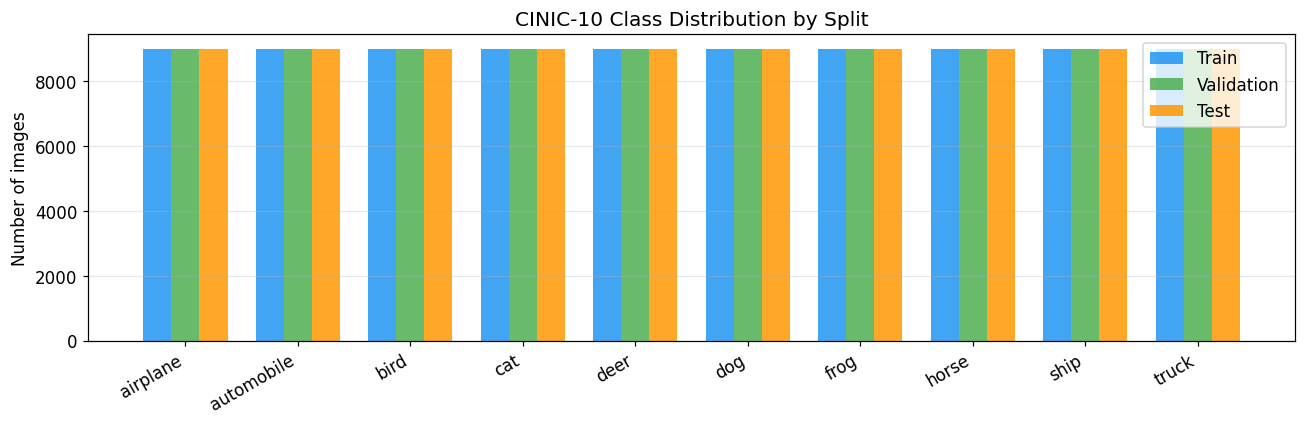

In [5]:
# Dataset statistics: per-class image counts across train/val/test splits
splits = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}
counts = {}
for split_name, split_dir in splits.items():
    counts[split_name] = {cls: len(list((split_dir / cls).iterdir()))
                          for cls in CINIC_CLASSES}

df_counts = pd.DataFrame(counts)
print(df_counts.to_string())
print(f'\nTotal images: {df_counts.sum().sum():,}')

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(CINIC_CLASSES))
w = 0.25
for i, (split_name, color) in enumerate(zip(splits, ['#2196F3', '#4CAF50', '#FF9800'])):
    ax.bar(x + i * w, df_counts[split_name], w, label=split_name, color=color, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(CINIC_CLASSES, rotation=30, ha='right')
ax.set_ylabel('Number of images')
ax.set_title('CINIC-10 Class Distribution by Split')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'dataset_class_distribution.png', bbox_inches='tight')
plt.show()

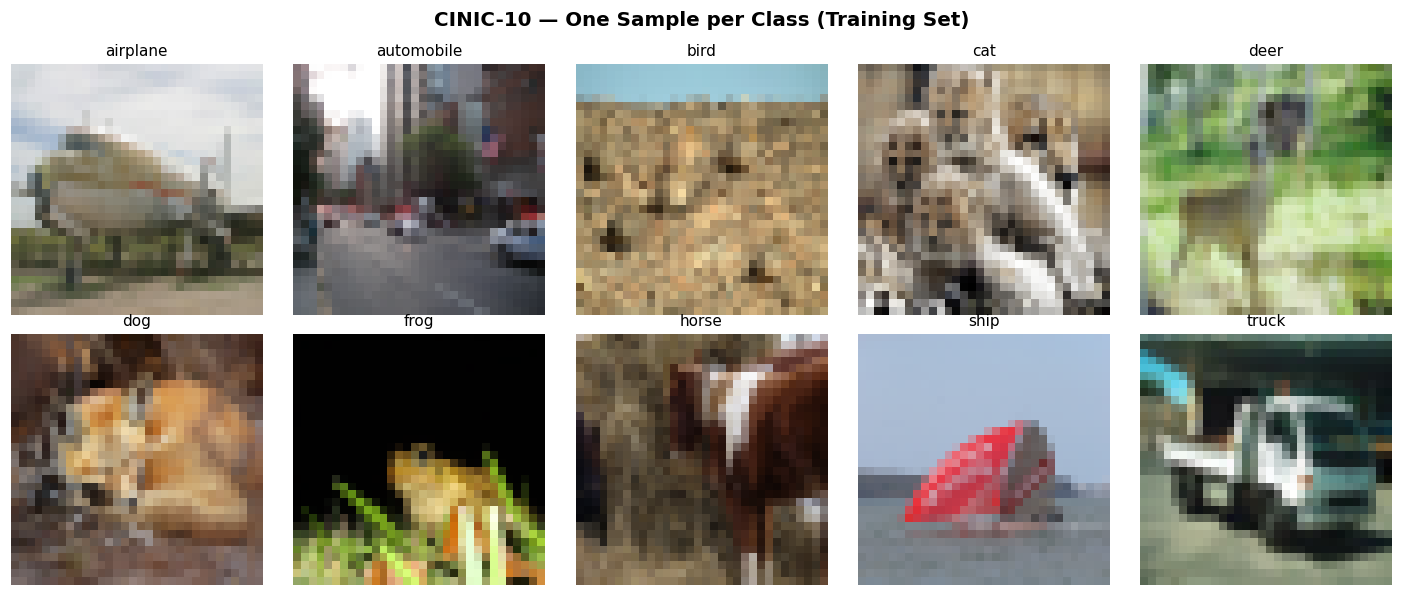

In [6]:
# Display one sample image per class from the training set
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle('CINIC-10 — One Sample per Class (Training Set)', fontsize=13, fontweight='bold')
for ax, cls in zip(axes.flat, CINIC_CLASSES):
    img_path = next((TRAIN_DIR / cls).iterdir())
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'dataset_sample_images.png', bbox_inches='tight')
plt.show()

---
## 2. Model architectures

Four CNNs: VGG Baseline (8 conv, ~2M params), ResNet Deep (18 conv + skip connections, 4.3M),
EfficientCNN (6 conv, ~0.5M), CNNWithRegularization (tuneable dropout, ~0.5M).

In [7]:
# Helper: count trainable parameters in a model
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
# Architecture registry: (name, factory_fn, kwargs) — used by training and results cells
arch_configs = [
    ('VGG Baseline', create_vgg_baseline, {}),
    ('ResNet Deep', create_resnet_deep, {}),
    ('EfficientCNN', create_efficient_cnn, {}),
    ('CNNWithRegularization', create_cnn_with_regularization, {'dropout_rate': 0.1}),
]

rows = []
for name, factory, kwargs in arch_configs:
    m = factory(**kwargs)
    rows.append({'Architecture': name, 'Parameters': f'{count_params(m):,}'})
print(f"{'Architecture':28s}  Params")
for r in rows:
    print(f"  {r['Architecture']:26s}  {r['Parameters']}")

Architecture                  Params
  VGG Baseline                1,388,970
  ResNet Deep                 4,327,754
  EfficientCNN                815,082
  CNNWithRegularization       1,342,698


---
## 3. Architecture comparison

15 epochs, SGD + cosine LR, AutoAugment(CIFAR10), per-model batch sizes.

In [9]:
# §3 Architecture comparison: output path, epoch count, and per-model batch/LR table
ARCH_CSV = RESULTS / 'arch_comparison_v2.csv'
ARCH_EPOCHS = 15

# Batch sizes and LRs follow the linear scaling rule: lr = 0.01 × (bs / 128)
# ResNet Deep is memory-constrained (wider feature maps), so bs=256 not 512.
_per_model = {
    'VGG Baseline': {'batch_size': 512,  'lr': 0.04, 'num_workers': 4},
    'ResNet Deep': {'batch_size': 256,  'lr': 0.02, 'num_workers': 4},
    'EfficientCNN': {'batch_size': 2048, 'lr': 0.08, 'num_workers': 8},
    'CNNWithRegularization': {'batch_size': 2048, 'lr': 0.08, 'num_workers': 8},
}

In [10]:
# Helper: build data loaders, train one architecture, and return epoch history
def _train_arch(name, factory, kwargs):
    cfg = _per_model.get(name, {'batch_size': 512, 'lr': 0.01, 'num_workers': 4})
    bs, lr, nw = cfg['batch_size'], cfg['lr'], cfg['num_workers']
    train_loader, val_loader = create_data_generators_strong(
        str(TRAIN_DIR), str(VAL_DIR), batch_size=bs, num_workers=nw)
    set_seeds(SEEDS[0])
    model     = factory(**kwargs).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ARCH_EPOCHS)
    print(f'\n--- {name} ({count_params(model):,} params, batch_size={bs}, lr={lr}) ---')
    history = train_model(
        model, train_loader, val_loader, optimizer,
        epochs=ARCH_EPOCHS, device=device, patience=5,
        scheduler=scheduler, label_smoothing=0.1,
    )
    return history

In [11]:
# Train all 4 architectures or load cached CSV results
if ARCH_CSV.exists():
    print('Loading pre-computed architecture results...')
    df_arch = pd.read_csv(ARCH_CSV)
    arch_histories = None
else:
    print('Training all architectures (this takes a few minutes)...')
    arch_histories, arch_results = {}, []
    for name, factory, kwargs in arch_configs:
        h = _train_arch(name, factory, kwargs)
        arch_histories[name] = h
        arch_results.append({
            'architecture': name,
            'best_val_accuracy': max(h['val_accuracy']),
            'final_val_accuracy': h['val_accuracy'][-1],
            'final_val_loss': h['val_loss'][-1],
            'epochs_trained': len(h['val_accuracy']),
        })
    df_arch = pd.DataFrame(arch_results)
    df_arch.to_csv(ARCH_CSV, index=False)
    print(f'\nSaved to {ARCH_CSV}')
col = 'best_val_accuracy' if 'best_val_accuracy' in df_arch.columns else 'val_accuracy'
print(df_arch[['architecture', col]].to_string(index=False))

Loading pre-computed architecture results...
         architecture  best_val_accuracy
         VGG Baseline           0.618367
          ResNet Deep           0.797500
         EfficientCNN           0.623900
CNNWithRegularization           0.668422


In [12]:
# Learning curves: plotted only when architectures were trained this session
if arch_histories:
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (name, _, __), color in zip(arch_configs, colors):
        h  = arch_histories[name]
        ep = range(1, len(h['val_accuracy']) + 1)
        axes[0].plot(ep, h['accuracy'], '--', color=color, alpha=0.5)
        axes[0].plot(ep, h['val_accuracy'], '-',  color=color, label=name)
        axes[1].plot(ep, h['loss'], '--', color=color, alpha=0.5)
        axes[1].plot(ep, h['val_loss'], '-',  color=color, label=name)
    for ax, ylabel, title in zip(
        axes, ['Accuracy', 'Loss'],
        ['Accuracy (solid=val, dashed=train)', 'Loss (solid=val, dashed=train)'],
    ):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Architecture Comparison — Learning Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'arch_learning_curves.png', bbox_inches='tight')
    plt.show()

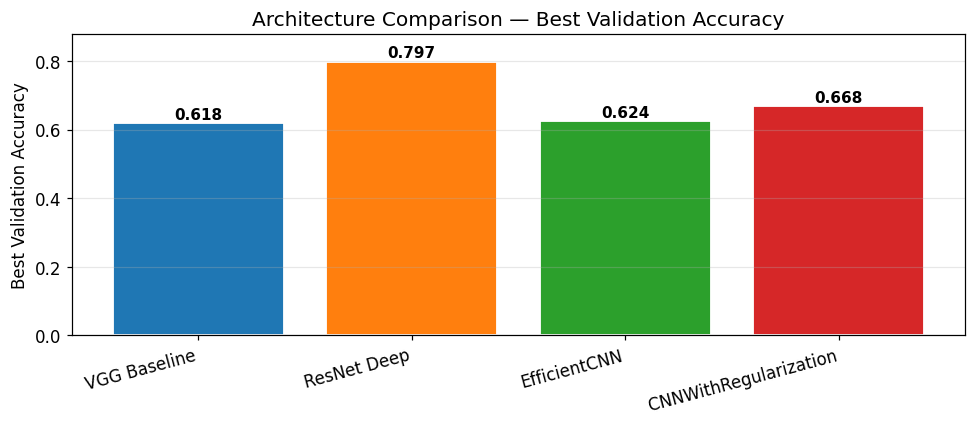

In [13]:
# Bar chart: best validation accuracy per architecture
col    = 'best_val_accuracy' if 'best_val_accuracy' in df_arch.columns else 'val_accuracy'
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df_arch['architecture'], df_arch[col],
              color=colors[:len(df_arch)], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, df_arch[col]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Architecture Comparison — Best Validation Accuracy')
ax.set_ylim(0, min(1.0, df_arch[col].max() + 0.08))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'arch_comparison_bar.png', bbox_inches='tight')
plt.show()

---
## 4. Hyperparameter analysis

VGG Baseline, 5 epochs, one parameter varied at a time. Four sweeps:
LR, batch size, optimiser, regularisation (dropout × weight decay grid).

In [14]:
# ── Generate HP sweep CSVs (skip if already present) ─────────────────────────
_hp_paths = [RESULTS / f'hp_v2_{k}.csv'
             for k in ('learning_rate', 'batch_size', 'optimizer', 'regularization')]
if not all(p.exists() for p in _hp_paths):
    print("Running HP sweeps with VGGBaseline (≈10-20 min on CPU, much faster on GPU/MPS)…")
    from hyperparameter_analysis import create_comprehensive_hyperparameter_analysis
    _hp = create_comprehensive_hyperparameter_analysis(
        create_vgg_baseline, str(TRAIN_DIR), str(VAL_DIR),
        epochs=3, data_fraction=0.25
    )
    RESULTS.mkdir(exist_ok=True)
    for _key, _rows in _hp.items():
        pd.DataFrame(_rows).to_csv(RESULTS / f'hp_v2_{_key}.csv', index=False)
        print(f"  saved hp_v2_{_key}.csv")
else:
    print("HP v2 CSVs found — skipping sweep.")


HP v2 CSVs found — skipping sweep.


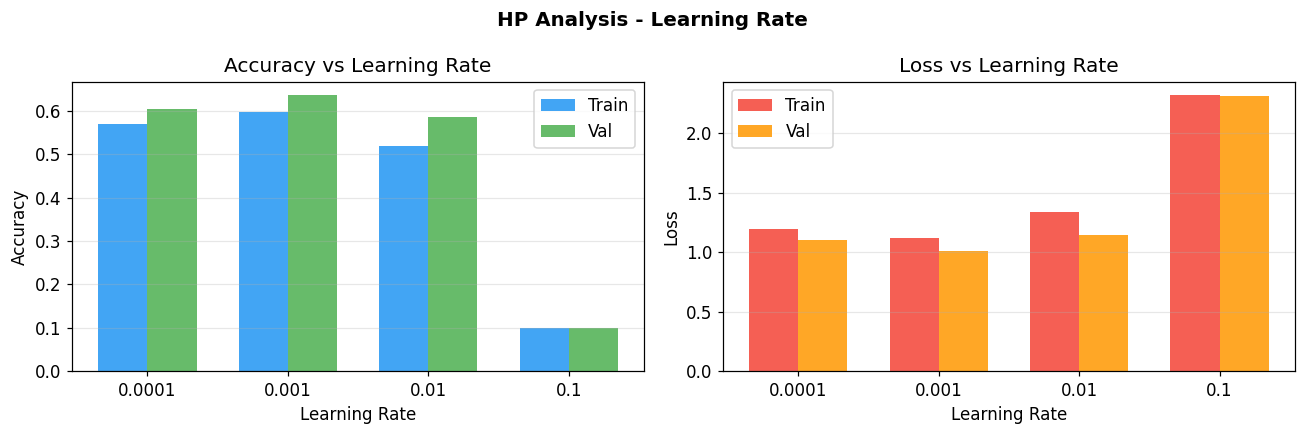

In [15]:
# §4 HP sweep — learning rate: accuracy and loss bar chart
df_lr = pd.read_csv(RESULTS / 'hp_v2_learning_rate.csv')
df_lr['learning_rate'] = df_lr['learning_rate'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(df_lr)); w = 0.35
axes[0].bar(x - w/2, df_lr['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_lr['val_accuracy'], w, label='Val', color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_lr['learning_rate'])
axes[0].set_xlabel('Learning Rate'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Learning Rate'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(x - w/2, df_lr['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_lr['val_loss'], w, label='Val', color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_lr['learning_rate'])
axes[1].set_xlabel('Learning Rate'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Learning Rate'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('HP Analysis - Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_lr_plot.png', bbox_inches='tight')
plt.show()

In [16]:
# Print best learning rate and note on lr=0.1 divergence
best = df_lr.loc[df_lr['val_accuracy'].idxmax()]
print(f'Best LR: {best["learning_rate"]} — val_acc={best["val_accuracy"]:.4f}')
print('Note: lr=0.1 collapses to random-chance accuracy (10%) — gradient steps are too large.')

Best LR: 0.001 — val_acc=0.6353
Note: lr=0.1 collapses to random-chance accuracy (10%) — gradient steps are too large.


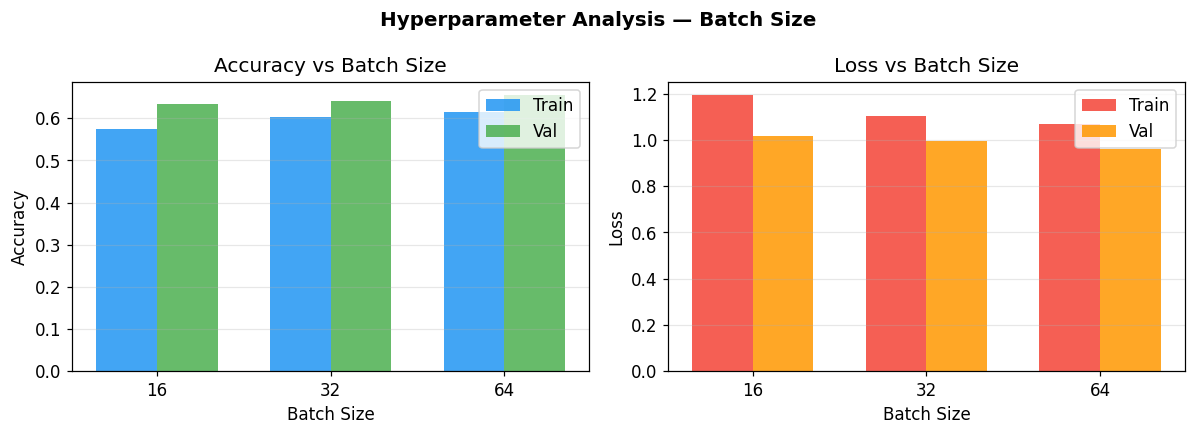

Best batch size: 64 — val_acc=0.6543


In [17]:
# HP sweep — batch size: accuracy and loss bar chart
df_bs = pd.read_csv(RESULTS / 'hp_v2_batch_size.csv')
df_bs['batch_size'] = df_bs['batch_size'].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(df_bs)); w = 0.35
axes[0].bar(x - w/2, df_bs['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_bs['val_accuracy'], w, label='Val', color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_bs['batch_size'])
axes[0].set_xlabel('Batch Size'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Batch Size'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(x - w/2, df_bs['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_bs['val_loss'], w, label='Val', color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_bs['batch_size'])
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Batch Size'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('Hyperparameter Analysis — Batch Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_bs_plot.png', bbox_inches='tight')
plt.show()
best = df_bs.loc[df_bs['val_accuracy'].idxmax()]
print(f'Best batch size: {best["batch_size"]} — val_acc={best["val_accuracy"]:.4f}')

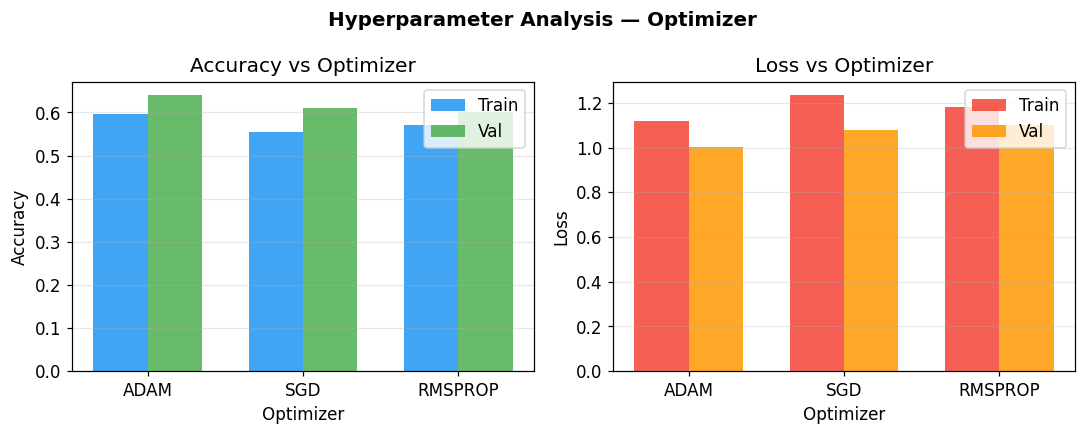

Best optimizer: adam — val_acc=0.6396


In [18]:
# HP sweep — optimizer: compare SGD, Adam, RMSprop
df_opt = pd.read_csv(RESULTS / 'hp_v2_optimizer.csv')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(df_opt)); w = 0.35
names = df_opt['optimizer'].str.upper()
axes[0].bar(x - w/2, df_opt['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_opt['val_accuracy'], w, label='Val', color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_xlabel('Optimizer'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Optimizer'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(x - w/2, df_opt['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_opt['val_loss'], w, label='Val', color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_xlabel('Optimizer'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Optimizer'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('Hyperparameter Analysis — Optimizer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_opt_plot.png', bbox_inches='tight')
plt.show()
best = df_opt.loc[df_opt['val_accuracy'].idxmax()]
print(f'Best optimizer: {best["optimizer"]} — val_acc={best["val_accuracy"]:.4f}')

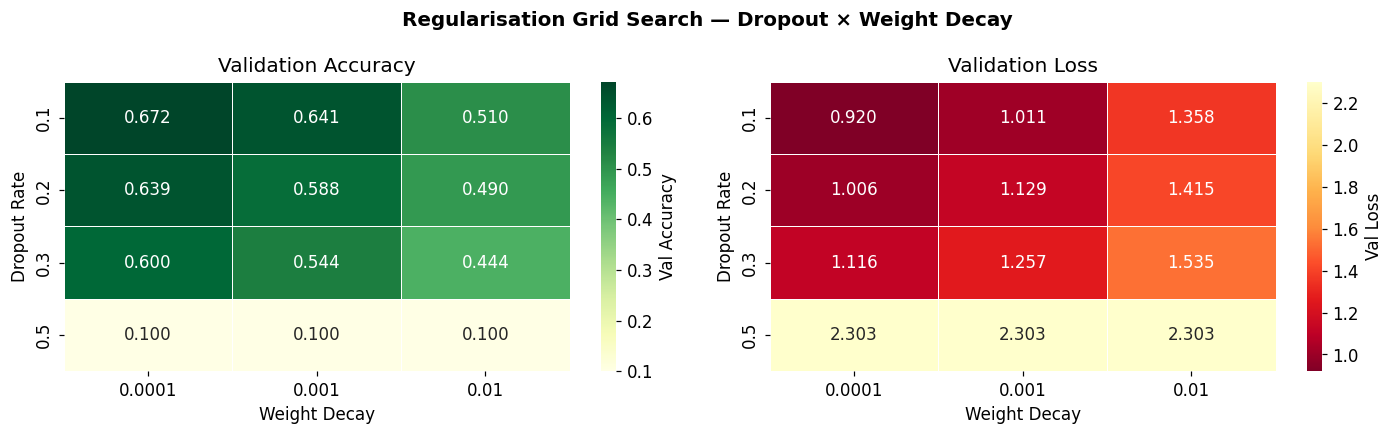

Best: dropout=0.1, wd=0.0001 → val_acc=0.6720
Note: dropout=0.5 collapses training to random guessing (10%) regardless of weight decay.


In [19]:
# HP sweep — regularisation: dropout_rate × weight_decay accuracy heatmap
df_reg = pd.read_csv(RESULTS / 'hp_v2_regularization.csv')
pivot_acc  = df_reg.pivot(index='dropout_rate', columns='weight_decay', values='val_accuracy')
pivot_loss = df_reg.pivot(index='dropout_rate', columns='weight_decay', values='val_loss')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(pivot_acc,  ax=axes[0], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Val Accuracy'})
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Weight Decay'); axes[0].set_ylabel('Dropout Rate')
sns.heatmap(pivot_loss, ax=axes[1], annot=True, fmt='.3f', cmap='YlOrRd_r',
            linewidths=0.5, cbar_kws={'label': 'Val Loss'})
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Weight Decay'); axes[1].set_ylabel('Dropout Rate')
plt.suptitle('Regularisation Grid Search — Dropout × Weight Decay', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_reg_heatmap.png', bbox_inches='tight')
plt.show()
best = df_reg.loc[df_reg['val_accuracy'].idxmax()]
print(f'Best: dropout={best["dropout_rate"]}, wd={best["weight_decay"]} → val_acc={best["val_accuracy"]:.4f}')
print('Note: dropout=0.5 collapses training to random guessing (10%) regardless of weight decay.')

---
## 5. Data augmentation study

Seven augmentation pipelines compared on VGG Baseline (5 epochs).

In [20]:
# §5 Augmentation: define 5 standard pipeline variants on one sample image
sample_path = next((TRAIN_DIR / 'airplane').iterdir())
src = Image.open(sample_path).convert('RGB')

augmentation_pipelines = {
    'Original': T.Compose([T.Resize((32, 32)), T.ToTensor()]),
    'Standard\n(rot+flip+aff)': T.Compose([
        T.Resize((32, 32)), T.RandomRotation(15),
        T.RandomHorizontalFlip(), T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ]),
    'Color\nJitter': T.Compose([
        T.Resize((32, 32)),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        T.ToTensor(),
    ]),
    'Minimal\n(flip only)': T.Compose([
        T.Resize((32, 32)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(),
    ]),
    'Crop +\nResize': T.Compose([
        T.Resize((38, 38)), T.RandomCrop(32), T.ToTensor(),
    ]),
}

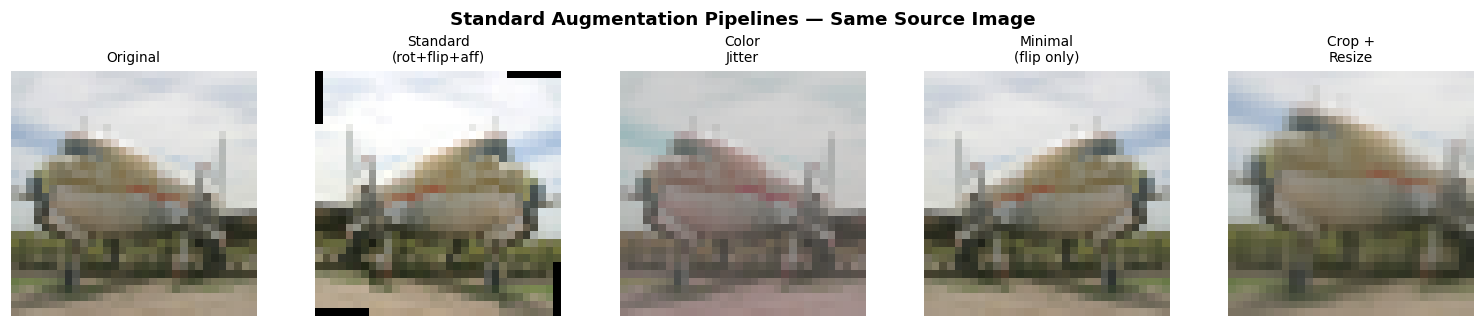

In [21]:
# Render all standard augmentation variants side by side on the same image
set_seeds(SEEDS[0])
fig, axes = plt.subplots(1, len(augmentation_pipelines), figsize=(14, 3))
fig.suptitle('Standard Augmentation Pipelines — Same Source Image', fontsize=12, fontweight='bold')
for ax, (name, transform) in zip(axes, augmentation_pipelines.items()):
    tensor = transform(src)
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_standard_vis.png', bbox_inches='tight')
plt.show()

In [22]:
# Helper: randomly place a solid-grey cutout mask of given size on a tensor
def apply_cutout(img_tensor, mask_size):
    result = img_tensor.clone()
    _, h, w = result.shape
    cy = np.random.randint(mask_size // 2, h - mask_size // 2)
    cx = np.random.randint(mask_size // 2, w - mask_size // 2)
    y1, y2 = max(0, cy - mask_size // 2), min(h, cy + mask_size // 2)
    x1, x2 = max(0, cx - mask_size // 2), min(w, cx + mask_size // 2)
    result[:, y1:y2, x1:x2] = 0.0
    return result

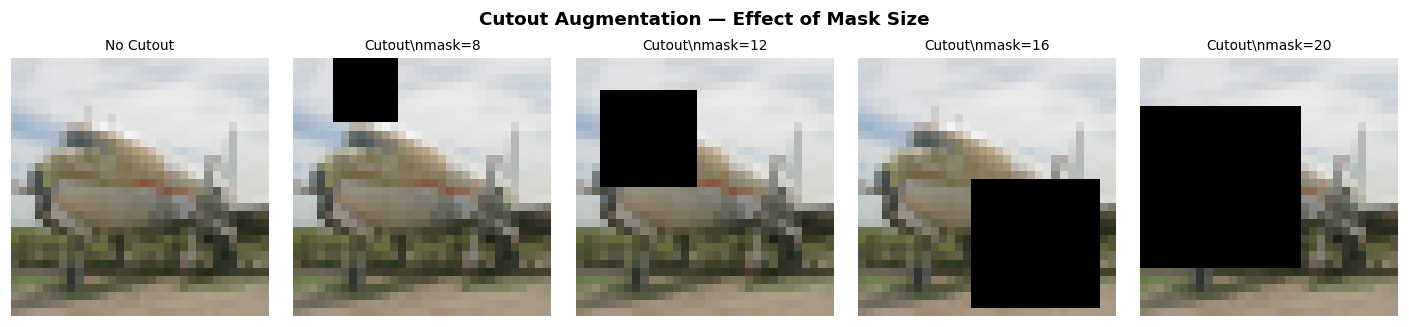

In [23]:
# Visualise cutout at mask sizes 8 / 12 / 16 / 20 on the same base image
base_tensor = T.Compose([T.Resize((32, 32)), T.ToTensor()])(src)
set_seeds(SEEDS[0])
variants = {'No Cutout': base_tensor}
for sz in [8, 12, 16, 20]:
    variants[f'Cutout\\nmask={sz}'] = apply_cutout(base_tensor.clone(), sz)

fig, axes = plt.subplots(1, len(variants), figsize=(13, 3))
fig.suptitle('Cutout Augmentation \u2014 Effect of Mask Size', fontsize=12, fontweight='bold')
for ax, (name, tensor) in zip(axes, variants.items()):
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_cutout_vis.png', bbox_inches='tight')
plt.show()

In [24]:
# ── Generate augmentation CSVs (skip if already present) ─────────────────────
_aug_paths = [RESULTS / 'aug_v2_standard.csv', RESULTS / 'aug_v2_advanced.csv']
if not all(p.exists() for p in _aug_paths):
    print("Running augmentation comparison with VGGBaseline (≈10 min on CPU)…")
    from augmentation_studies import compare_augmentation_approaches
    _aug = compare_augmentation_approaches(
        create_vgg_baseline, str(TRAIN_DIR), str(VAL_DIR), epochs=5, batch_size=32
    )
    RESULTS.mkdir(exist_ok=True)
    for _key, _rows in _aug.items():
        pd.DataFrame(_rows).to_csv(RESULTS / f'aug_v2_{_key}.csv', index=False)
        print(f"  saved aug_v2_{_key}.csv")
else:
    print("Augmentation v2 CSVs found — skipping.")


Augmentation v2 CSVs found — skipping.


In [25]:
# Load augmentation results and map internal keys to display labels
df_std = pd.read_csv(RESULTS / 'aug_v2_standard.csv')
df_adv = pd.read_csv(RESULTS / 'aug_v2_advanced.csv')

label_map_std = {
    'standard': 'Standard\n(rot+flip+aff)',
    'color_jitter': 'Color Jitter',
    'minimal': 'Minimal\n(flip only)',
    'crop_resize': 'Crop+Resize',
}
label_map_adv = {
    'cutout': 'Cutout',
    'mixup': 'Mixup',
    'autoaugment_like': 'AutoAugment-like',
}
df_std['label'] = df_std['augmentation'].map(label_map_std).fillna(df_std['augmentation'])
df_adv['label'] = df_adv['augmentation'].map(label_map_adv).fillna(df_adv['augmentation'])

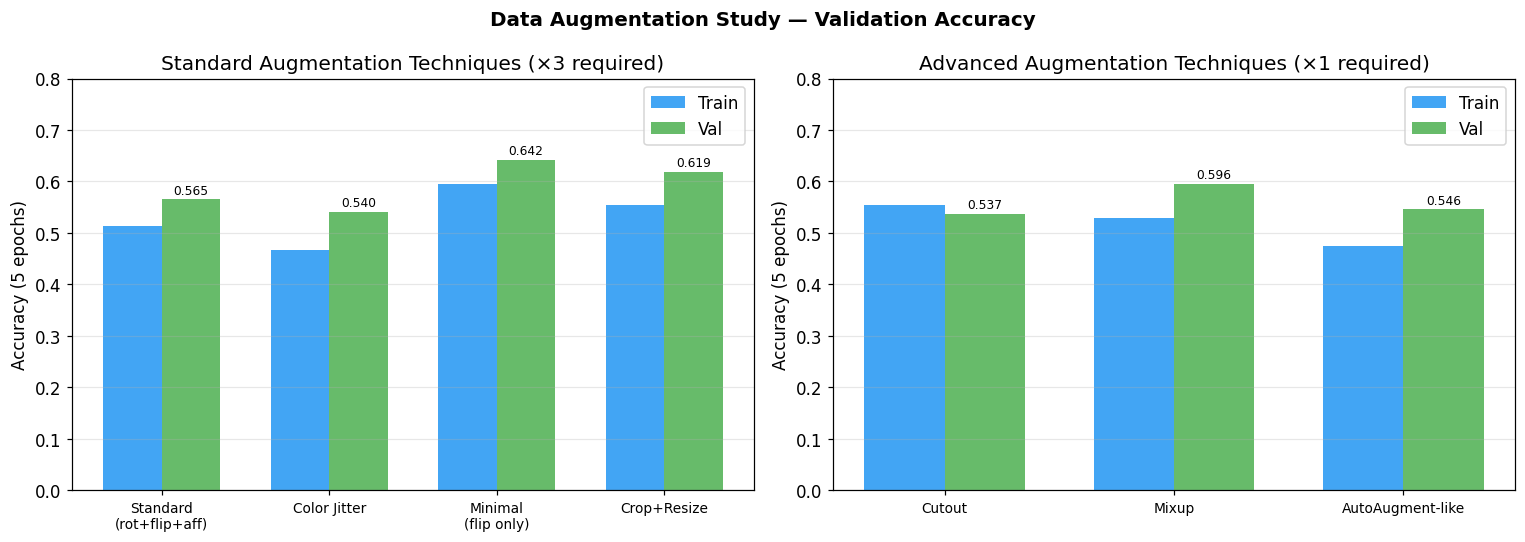

Best standard: minimal         val_acc=0.6423
Best advanced: mixup           val_acc=0.5957


In [26]:
# Bar chart: val accuracy for all standard and advanced augmentation pipelines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], df_std, 'Standard Augmentation Techniques (×3 required)'),
    (axes[1], df_adv, 'Advanced Augmentation Techniques (×1 required)'),
]:
    x = np.arange(len(df)); w = 0.35
    ax.bar(x - w/2, df['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
    bars = ax.bar(x + w/2, df['val_accuracy'], w, label='Val', color='#4CAF50', alpha=0.85)
    for bar, val in zip(bars, df['val_accuracy']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(df['label'], fontsize=9)
    ax.set_ylabel('Accuracy (5 epochs)')
    ax.set_title(title); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 0.80)
plt.suptitle('Data Augmentation Study — Validation Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_comparison_bar.png', bbox_inches='tight')
plt.show()

best_std = df_std.loc[df_std['val_accuracy'].idxmax()]
best_adv = df_adv.loc[df_adv['val_accuracy'].idxmax()]
print(f'Best standard: {best_std["augmentation"]:15s} val_acc={best_std["val_accuracy"]:.4f}')
print(f'Best advanced: {best_adv["augmentation"]:15s} val_acc={best_adv["val_accuracy"]:.4f}')

---
## 6. Statistical significance

3 seeds × 2 configurations × 15 epochs. Tests whether the HP-sweep winner holds up.

In [27]:
# §6 Statistical significance: compare vanilla baseline vs best-reg config over 3 seeds
STATS_CSV   = RESULTS / 'statistical_significance_v2.csv'
STAT_EPOCHS = 15

# No augmentation: isolates the effect of regularisation hyperparameters alone.
# batch_size matches per-model sizes from §3 for consistent memory profiles.
configs = [
    ('Baseline\n(dropout=0.25, wd=0)', create_vgg_baseline, {}, {}, False, 512),
    ('Best Reg.\n(dropout=0.1, wd=1e-4)', create_cnn_with_regularization,
     {'dropout_rate': 0.1}, {'weight_decay': 1e-4}, False, 2048),
]

In [28]:
# Run both configs with 3 different seeds or load cached results
if STATS_CSV.exists():
    print('Loading cached results...')
    df_stats = pd.read_csv(STATS_CSV)
else:
    rows = []
    for config_name, factory, model_kwargs, optim_kwargs, augment, batch_size in configs:
        train_loader, val_loader = create_data_generators(
            str(TRAIN_DIR), str(VAL_DIR), batch_size=batch_size, augment=augment)
        for seed in SEEDS:
            set_seeds(seed)
            model     = factory(**model_kwargs).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, **optim_kwargs)
            label = config_name.replace('\n', ' ')
            print(f'{label}  seed={seed}  batch_size={batch_size}')
            history = train_model(model, train_loader, val_loader, optimizer,
                                  epochs=STAT_EPOCHS, device=device, patience=5)
            rows.append({'config': config_name, 'seed': seed,
                         'best_val_acc': max(history['val_accuracy']),
                         'final_val_acc': history['val_accuracy'][-1],
                         'final_val_loss': history['val_loss'][-1]})
    df_stats = pd.DataFrame(rows)
    df_stats.to_csv(STATS_CSV, index=False)
    print(f'\nSaved to {STATS_CSV}')

Loading cached results...


In [29]:
# Print mean ± std best validation accuracy across the 3 seeds per config
summary = df_stats.groupby('config')['best_val_acc'].agg(['mean', 'std']).reset_index()
summary.columns = ['Configuration', 'Mean Val Acc', 'Std Dev']
summary['Mean ± Std'] = summary.apply(lambda r: f"{r['Mean Val Acc']:.4f} ± {r['Std Dev']:.4f}", axis=1)
print('\n', summary[['Configuration', 'Mean ± Std']].to_string(index=False))


                     Configuration      Mean ± Std
   Baseline\n(dropout=0.25, wd=0) 0.6865 ± 0.0064
Best Reg.\n(dropout=0.1, wd=1e-4) 0.6764 ± 0.0025


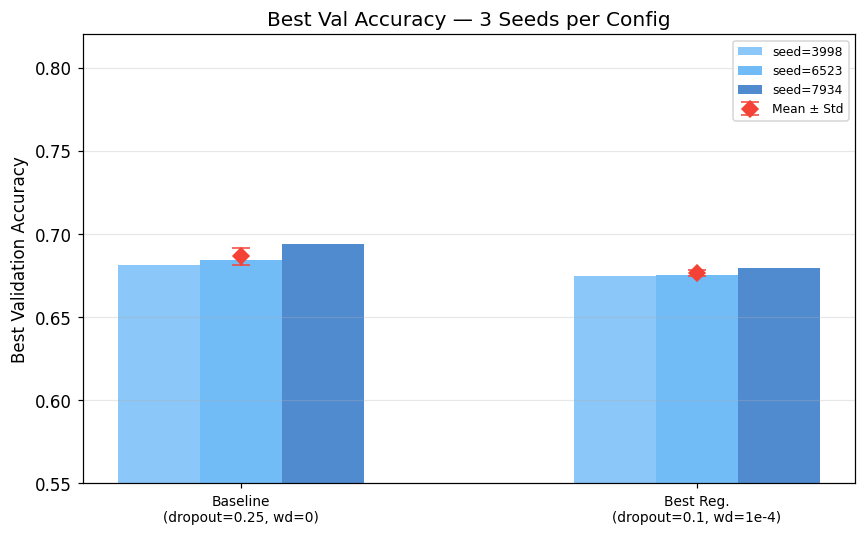

In [30]:
# Bar chart: per-seed accuracy with mean±std error bars for each config
configs_unique = df_stats['config'].unique()
x = np.arange(len(configs_unique))
w = 0.18
seed_colors = ['#64B5F6', '#42A5F5', '#1565C0']
fig, ax0 = plt.subplots(figsize=(8, 5))
seeds_in_csv = sorted(df_stats['seed'].unique())  # use seeds from CSV, not session (may differ)
for i, (seed, color) in enumerate(zip(seeds_in_csv, seed_colors)):
    vals = [
        df_stats[(df_stats['config'] == c) & (df_stats['seed'] == seed)]['best_val_acc'].values[0]
        for c in configs_unique
    ]
    ax0.bar(x + (i - 1) * w, vals, w, label=f'seed={seed}', alpha=0.75, color=color)
for j, cfg in enumerate(configs_unique):
    vals = df_stats[df_stats['config'] == cfg]['best_val_acc'].values
    ax0.errorbar(x[j], vals.mean(), yerr=vals.std(),
                 fmt='D', color='#F44336', capsize=6, markersize=7,
                 linewidth=2, label='Mean ± Std' if j == 0 else '')
ax0.set_xticks(x); ax0.set_xticklabels(configs_unique, fontsize=9)
ax0.set_ylabel('Best Validation Accuracy')
ax0.set_title('Best Val Accuracy — 3 Seeds per Config')
ax0.legend(fontsize=8); ax0.grid(axis='y', alpha=0.3); ax0.set_ylim(0.55, 0.82)
plt.tight_layout()
plt.savefig(RESULTS / 'stats_significance_plot.png', bbox_inches='tight')
plt.show()

---
## 7. Few-shot learning

### 7.1 Naive baseline — train from scratch

In [31]:
# §7.1 Naive few-shot: run evaluation or skip if CSV already cached
_fs_csv = RESULTS / 'few_shot_results.csv'
if not _fs_csv.exists():
    print("Running naive few-shot evaluation (≈5 min on CPU)…")
    from few_shot_learning import evaluate_few_shot_performance
    _fs = evaluate_few_shot_performance(
        create_few_shot_cnn, str(TRAIN_DIR), str(VAL_DIR),
        few_shot_configs=[1, 5, 10, 50], epochs=15, batch_size=256
    )
    RESULTS.mkdir(exist_ok=True)
    pd.DataFrame(_fs['few_shot']).to_csv(_fs_csv, index=False)
    print("  saved few_shot_results.csv")
else:
    print("few_shot_results.csv found — skipping.")

few_shot_results.csv found — skipping.


In [32]:
# §7.3 Reduced dataset: run experiment or skip if CSV already cached
_rd_csv = RESULTS / 'reduced_dataset_results.csv'
if not _rd_csv.exists():
    print("Running reduced-dataset experiment (≈5 min on CPU)…")
    from evaluation import run_reduced_dataset_experiment
    _rd = run_reduced_dataset_experiment(
        create_vgg_baseline, str(TRAIN_DIR), str(VAL_DIR),
        fractions=[0.1, 0.25, 0.5, 1.0], epochs=5, batch_size=256
    )
    RESULTS.mkdir(exist_ok=True)
    pd.DataFrame(_rd).to_csv(_rd_csv, index=False)
    print("  saved reduced_dataset_results.csv")
else:
    print("reduced_dataset_results.csv found — skipping.")

reduced_dataset_results.csv found — skipping.


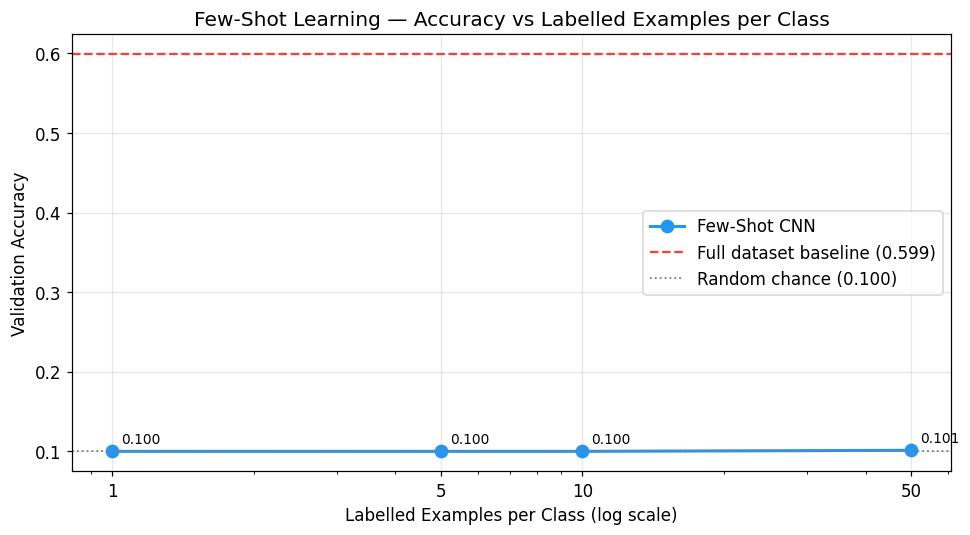

In [33]:
# Plot naive few-shot accuracy vs labelled examples per class
df_fs = pd.read_csv(RESULTS / 'few_shot_results.csv')
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
full_val_acc = df_rd.loc[df_rd['fraction'] == 1.0, 'val_accuracy'].values[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_fs['samples_per_class'], df_fs['val_accuracy'],
        'o-', color='#2196F3', linewidth=2, markersize=8, label='Few-Shot CNN')
ax.axhline(full_val_acc, color='#F44336', linestyle='--', linewidth=1.5,
           label=f'Full dataset baseline ({full_val_acc:.3f})')
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='Random chance (0.100)')
for _, row in df_fs.iterrows():
    ax.annotate(f"{row['val_accuracy']:.3f}",
                (row['samples_per_class'], row['val_accuracy']),
                textcoords='offset points', xytext=(6, 5), fontsize=9)
ax.set_xscale('log')
ax.set_xticks(df_fs['samples_per_class'])
ax.set_xticklabels(df_fs['samples_per_class'].astype(str))
ax.set_xlabel('Labelled Examples per Class (log scale)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Few-Shot Learning — Accuracy vs Labelled Examples per Class')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'few_shot_plot.png', bbox_inches='tight')
plt.show()

In [34]:
# Print few-shot accuracy table and gap to full-dataset baseline
print(df_fs[['samples_per_class', 'train_accuracy', 'val_accuracy', 'val_loss']].to_string(index=False))
print(f'\nFull-dataset baseline: {full_val_acc:.4f}')
gap = full_val_acc - df_fs['val_accuracy'].max()
print(f'Gap (full vs best few-shot): {gap:.4f}')

 samples_per_class  train_accuracy  val_accuracy  val_loss
                 1           0.300        0.1000  2.304586
                 5           0.180        0.1000  2.305307
                10           0.270        0.1000  2.303542
                50           0.292        0.1013  2.684294

Full-dataset baseline: 0.5988
Gap (full vs best few-shot): 0.4975


### 7.2 Prototypical Networks

In [35]:
# §7.2 ProtoNet: 4-block CNN encoder with L2-normalised 64-dim output
class EmbeddingNetwork(nn.Module):
    def __init__(self, embedding_dim=64, dropout=0.15):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(dropout),
            )
        self.encoder = nn.Sequential(
            conv_block(3, 64), conv_block(64, 64),
            conv_block(64, 64), conv_block(64, 64),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.proj = nn.Linear(64, embedding_dim)

    def forward(self, x):
        z = self.proj(self.encoder(x))
        return F.normalize(z, dim=1)

In [36]:
# Dataset wrapper: randomly samples N-way K-shot + N-query episodes at runtime
class EpisodicDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform, n_way, k_shot, n_query, n_episodes):
        self.base = ImageFolder(str(root), transform=transform)
        self.n_way, self.k_shot, self.n_query = n_way, k_shot, n_query
        self.n_episodes = n_episodes
        self.class_to_idx = defaultdict(list)
        for idx, (_, label) in enumerate(self.base.samples):
            self.class_to_idx[label].append(idx)
        self.all_classes = sorted(self.class_to_idx)
    def __len__(self): return self.n_episodes
    def __getitem__(self, _):
        classes = np.random.choice(len(self.all_classes), self.n_way, replace=False)
        support_imgs, query_imgs, support_lbl, query_lbl = [], [], [], []
        for new_lbl, cls in enumerate(classes):
            idxs = np.random.choice(self.class_to_idx[self.all_classes[cls]],
                                    self.k_shot + self.n_query, replace=False)
            for i, idx in enumerate(idxs):
                img, _ = self.base[idx]
                if i < self.k_shot:
                    support_imgs.append(img); support_lbl.append(new_lbl)
                else:
                    query_imgs.append(img); query_lbl.append(new_lbl)
        images = torch.stack(support_imgs + query_imgs)
        labels = torch.tensor(support_lbl + query_lbl, dtype=torch.long)
        return images, labels

In [37]:
# Episode forward pass: compute mean prototypes, distances, loss, and accuracy
def prototypical_step(model, images, n_way, k_shot, n_query, device):
    images = images.to(device)
    z = model(images)
    support_size = n_way * k_shot
    prototypes = z[:support_size].view(n_way, k_shot, -1).mean(1)
    queries = z[support_size:]
    dists = torch.cdist(queries, prototypes)
    q_labels = torch.arange(n_way).repeat_interleave(n_query).to(device)
    loss = F.cross_entropy(-dists, q_labels)
    acc = (dists.argmin(1) == q_labels).float().mean().item()
    return loss, acc

In [38]:
# Sanity check: verify embedding shape and L2 normalisation
enc = EmbeddingNetwork(embedding_dim=64)
print(f'EmbeddingNetwork parameters: {count_params(enc):,}')
test_out = enc(torch.zeros(2, 3, 32, 32))
print(f'Output shape: {test_out.shape}  (L2 norm: {test_out.norm(dim=1).mean():.3f})')

transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])  # no augmentation for val/test episodes
print('ProtoNet classes ready.')

EmbeddingNetwork parameters: 117,248
Output shape: torch.Size([2, 64])  (L2 norm: 1.000)
ProtoNet classes ready.


In [39]:
# Build model, optimiser, data loaders if no checkpoint found; set _needs_training flag
if not PROTO_PT.exists():
    set_seeds(SEEDS[0])
    proto_net = EmbeddingNetwork(embedding_dim=64).to(device)
    optimizer = torch.optim.Adam(proto_net.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=PROTO_EPOCHS, eta_min=1e-5)
    train_transform = T.Compose([
        T.Resize((32, 32)), T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(), T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ])
    val_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
    train_ep_ds = EpisodicDataset(TRAIN_DIR, train_transform, N_WAY, K_SHOT, N_QUERY,
                                  n_episodes=EPISODES_PER_EPOCH * PROTO_EPOCHS)
    val_ep_ds = EpisodicDataset(VAL_DIR, val_transform, N_WAY, K_SHOT, N_QUERY,
                                n_episodes=200)
    train_ep_loader = DataLoader(train_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    val_ep_loader = DataLoader(val_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    history, best_val_acc, best_state = [], 0.0, None
    patience_counter, patience = 0, 10
    ep_iter = iter(train_ep_loader)
    _needs_training = True  # guard for the training loop cell below
else:
    _needs_training = False

NameError: name 'PROTO_PT' is not defined

In [ ]:
if not PROTO_PT.exists():
    set_seeds(SEEDS[0])
    proto_net = EmbeddingNetwork(embedding_dim=64).to(device)
    optimizer = torch.optim.Adam(proto_net.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=PROTO_EPOCHS, eta_min=1e-5)
    train_transform = T.Compose([
        T.Resize((32, 32)), T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(), T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ])
    val_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
    train_ep_ds = EpisodicDataset(TRAIN_DIR, train_transform, N_WAY, K_SHOT, N_QUERY,
                                  n_episodes=EPISODES_PER_EPOCH * PROTO_EPOCHS)
    val_ep_ds = EpisodicDataset(VAL_DIR, val_transform, N_WAY, K_SHOT, N_QUERY,
                                n_episodes=200)
    train_ep_loader = DataLoader(train_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    val_ep_loader = DataLoader(val_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    history, best_val_acc, best_state = [], 0.0, None
    patience_counter, patience = 0, 10
    ep_iter = iter(train_ep_loader)
    _needs_training = True
else:
    _needs_training = False

In [ ]:
# Helper: run one training pass + validation pass over episodic data loaders
def _proto_epoch(proto_net, ep_iter, val_ep_loader, optimizer, scheduler):
    proto_net.train()
    t_losses, t_accs = [], []
    for _ in range(EPISODES_PER_EPOCH):
        imgs, _ = next(ep_iter)
        imgs = imgs.squeeze(0)
        optimizer.zero_grad()
        loss, acc = prototypical_step(proto_net, imgs, N_WAY, K_SHOT, N_QUERY, device)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(proto_net.parameters(), max_norm=5.0)
        optimizer.step()
        t_losses.append(loss.item()); t_accs.append(acc)
    proto_net.train(mode=False)
    v_losses, v_accs = [], []
    with torch.no_grad():
        for imgs, _ in val_ep_loader:
            imgs = imgs.squeeze(0)
            loss, acc = prototypical_step(proto_net, imgs, N_WAY, K_SHOT, N_QUERY, device)
            v_losses.append(loss.item()); v_accs.append(acc)
    proto_net.train(); scheduler.step()
    return {'train_loss': np.mean(t_losses), 'train_acc': np.mean(t_accs),
            'val_loss': np.mean(v_losses), 'val_acc': np.mean(v_accs),
            'lr': optimizer.param_groups[0]['lr']}

In [ ]:
# ProtoNet training loop with early stopping; saves best checkpoint
if _needs_training:
    for epoch in range(PROTO_EPOCHS):
        row = _proto_epoch(proto_net, ep_iter, val_ep_loader, optimizer, scheduler)
        row['epoch'] = epoch + 1
        history.append(row)
        if row['val_acc'] > best_val_acc:
            best_val_acc = row['val_acc']
            best_state = {k: v.clone() for k, v in proto_net.state_dict().items()}
            patience_counter = 0
            marker = '  *best*'
        else:
            patience_counter += 1
            marker = ''
        print(f'Epoch {epoch+1:3d}/{PROTO_EPOCHS}  '
              f'loss {row["train_loss"]:.4f}  acc {row["train_acc"]:.4f}  '
              f'val_loss {row["val_loss"]:.4f}  val_acc {row["val_acc"]:.4f}{marker}')
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}'); break
    proto_net.load_state_dict(best_state)
    torch.save(proto_net.state_dict(), PROTO_PT)
    df_proto_hist = pd.DataFrame(history)
    df_proto_hist.to_csv(PROTO_CSV, index=False)
    print(f'Best val_acc: {best_val_acc:.4f}  | Saved to {PROTO_PT}')

In [ ]:
# Plot training curves if available
if not df_proto_hist.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df_proto_hist['epoch'], df_proto_hist['train_acc'], '-', label='Train', alpha=0.7)
    axes[0].plot(df_proto_hist['epoch'], df_proto_hist['val_acc'], '-', label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Episode Accuracy')
    axes[0].set_title(f'ProtoNet Accuracy ({N_WAY}-way {K_SHOT}-shot)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(df_proto_hist['epoch'], df_proto_hist['train_loss'], '-', label='Train', alpha=0.7)
    axes[1].plot(df_proto_hist['epoch'], df_proto_hist['val_loss'], '-', label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Prototypical Loss')
    axes[1].set_title('ProtoNet Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Prototypical Network — Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'protonet_training_curves.png', bbox_inches='tight')
    plt.show()

In [ ]:
# Evaluate ProtoNet on 600 test episodes for 1-shot and 5-shot accuracy
print('Evaluating ProtoNet on test set...')
proto_net.train(mode=False)
proto_results = []
N_EVAL_EPISODES = 600  # enough episodes for a stable 95% CI estimate

for k_shot_eval in [1, 5]:
    test_ep_ds = EpisodicDataset(TEST_DIR, transform, N_WAY, k_shot_eval, N_QUERY,
                                 n_episodes=N_EVAL_EPISODES)
    test_ep_loader = DataLoader(test_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    accs = []
    with torch.no_grad():
        for imgs, _ in test_ep_loader:
            imgs = imgs.squeeze(0)
            _, acc = prototypical_step(proto_net, imgs, N_WAY, k_shot_eval, N_QUERY, device)
            accs.append(acc)
    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    ci95     = 1.96 * std_acc / np.sqrt(N_EVAL_EPISODES)  # 95% confidence interval
    proto_results.append({
        'k_shot': k_shot_eval,
        'mean_acc': mean_acc, 'std_acc': std_acc, 'ci95': ci95
    })
    print(f'  {N_WAY}-way {k_shot_eval}-shot: {mean_acc:.4f} ± {std_acc:.4f}  (95% CI ±{ci95:.4f})')

In [ ]:
# Save ProtoNet evaluation results (mean_acc, std_acc, ci95) to CSV
df_proto_eval = pd.DataFrame(proto_results)
df_proto_eval.to_csv(RESULTS / 'protonet_evaluation.csv', index=False)

In [ ]:
# Comparison plot: ProtoNet 1-shot/5-shot vs naive few-shot baseline
df_naive = pd.read_csv(RESULTS / 'few_shot_results.csv')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_naive['samples_per_class'], df_naive['val_accuracy'],
        'o--', color='#F44336', linewidth=2, markersize=7, label='Naive (train from scratch)')
r1 = df_proto_eval[df_proto_eval['k_shot'] == 1].iloc[0]
r5 = df_proto_eval[df_proto_eval['k_shot'] == 5].iloc[0]
ax.errorbar([1], [r1['mean_acc']], yerr=[r1['ci95']], fmt='s', color='#2196F3',
            capsize=7, markersize=9, linewidth=2, label=f'ProtoNet 1-shot ({r1["mean_acc"]:.3f} ± {r1["ci95"]:.3f})')
ax.errorbar([5], [r5['mean_acc']], yerr=[r5['ci95']], fmt='s', color='#1565C0',
            capsize=7, markersize=9, linewidth=2, label=f'ProtoNet 5-shot ({r5["mean_acc"]:.3f} ± {r5["ci95"]:.3f})')
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='Random chance (0.100)')
ax.set_xscale('log')
ax.set_xticks([1, 5, 10, 50]); ax.set_xticklabels(['1', '5', '10', '50'])
ax.set_xlabel('Support Examples per Class (K)'); ax.set_ylabel('Accuracy')
ax.set_title(f'Few-Shot Comparison: ProtoNet vs Naive ({N_WAY}-way, {N_EVAL_EPISODES} episodes)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'protonet_vs_naive.png', bbox_inches='tight')
plt.show()

In [ ]:
# Print numeric ProtoNet vs naive few-shot comparison at 1 and 5 shots
print(f'Naive 1 sample/class: {df_naive.loc[df_naive["samples_per_class"]==1, "val_accuracy"].values[0]:.4f}')
print(f'Naive 5 samples/class: {df_naive.loc[df_naive["samples_per_class"]==5, "val_accuracy"].values[0]:.4f}')
print(f'ProtoNet 1-shot: {r1["mean_acc"]:.4f} ± {r1["ci95"]:.4f}')
print(f'ProtoNet 5-shot: {r5["mean_acc"]:.4f} ± {r5["ci95"]:.4f}')

---
### 7.3 Reduced dataset experiment

VGG Baseline on 10%, 25%, 50%, 100% of training data.

In [ ]:
# §7.3 Reduced dataset: learning curve by fraction and by sample count
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(df_rd['fraction'] * 100, df_rd['val_accuracy'], 'o-', color='#2196F3', linewidth=2, markersize=8)
for _, row in df_rd.iterrows():
    axes[0].annotate(f"{row['val_accuracy']:.3f}",
                     (row['fraction'] * 100, row['val_accuracy']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('Training Set Size (%)'); axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Learning Curve (by fraction)'); axes[0].grid(alpha=0.3)
axes[1].plot(df_rd['num_train_samples'], df_rd['val_accuracy'], 's-', color='#4CAF50', linewidth=2, markersize=8)
for _, row in df_rd.iterrows():
    axes[1].annotate(f"{int(row['num_train_samples']):,}",
                     (row['num_train_samples'], row['val_accuracy']),
                     textcoords='offset points', xytext=(4, -15), fontsize=8, color='gray')
axes[1].set_xlabel('Number of Training Samples'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Learning Curve (by sample count)'); axes[1].grid(alpha=0.3)
plt.suptitle('Reduced Dataset Experiment — Accuracy vs Training Set Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'reduced_dataset_plot.png', bbox_inches='tight')
plt.show()

In [ ]:
# Print accuracy at 10% and 100% training data and the absolute gain
acc_10 = df_rd.loc[df_rd['fraction'] == 0.10, 'val_accuracy'].values[0]
acc_100 = df_rd.loc[df_rd['fraction'] == 1.00, 'val_accuracy'].values[0]
print(f'Accuracy at 10% data:  {acc_10:.4f}')
print(f'Accuracy at 100% data: {acc_100:.4f}')
print(f'Gain 10% → 100%: +{acc_100 - acc_10:.4f}')

---
## 8. Final test-set evaluation

VGG Baseline (20 epochs) on the held-out test split (90k images).

In [ ]:
# §8 Test evaluation: train VGGBaseline checkpoint if not found, then load it
if not VGG_BASE_PT.exists():
    print('Checkpoint not found — training VGGBaseline for 20 epochs...')
    set_seeds(SEEDS[0])
    _train_loader, _val_loader = create_data_generators_strong(str(TRAIN_DIR), str(VAL_DIR))
    _vgg_train = create_vgg_baseline().to(device)
    _optimizer = torch.optim.SGD(_vgg_train.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    _scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(_optimizer, T_max=20)
    train_model(_vgg_train, _train_loader, _val_loader, _optimizer,
                epochs=20, device=device, patience=5,
                checkpoint_path=str(VGG_BASE_PT),
                scheduler=_scheduler, label_smoothing=0.1)
    del _train_loader, _val_loader, _vgg_train, _optimizer
    print(f'Saved to {VGG_BASE_PT}')

model_test = create_vgg_baseline().to(device)
model_test.load_state_dict(torch.load(VGG_BASE_PT, map_location=device))
model_test.train(mode=False)
print('Loaded vgg_baseline.pt')

In [ ]:
# Run inference on the test set; collect logits, predictions, and softmax probabilities
test_transform = T.Compose([
    T.Resize((32, 32)), T.ToTensor(), T.Normalize(CINIC10_MEAN, CINIC10_STD),
])  # no augmentation at test time
test_dataset = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
print(f'Test samples: {len(test_dataset):,} | Classes: {test_dataset.classes}')

criterion = nn.CrossEntropyLoss()
test_loss, test_correct = 0.0, 0
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model_test(images)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)  # probabilities needed for per-class analysis
        preds = logits.argmax(dim=1)
        test_loss += loss.item() * images.size(0)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [ ]:
# Convert lists to arrays and compute overall test accuracy and loss
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
test_acc = test_correct / len(test_dataset)
test_loss /= len(test_dataset)
print(f'\nTest Accuracy: {test_acc:.4f}  ({test_correct:,}/{len(test_dataset):,})')
print(f'Test Loss:     {test_loss:.4f}')

In [ ]:
# Confusion matrices: raw counts (left) and row-normalised recall (right)
cm = confusion_matrix(all_labels, all_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise → per-class recall

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=axes[0], linewidths=0.4)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (counts)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=axes[1], linewidths=0.4, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (normalised per row)')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle(f'VGGBaseline — Test Accuracy: {test_acc:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'test_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
# Per-class precision, recall, F1, support from classification report
per_class_acc = cm_norm.diagonal()
report = classification_report(all_labels, all_preds, target_names=CINIC_CLASSES, output_dict=True)
df_report = pd.DataFrame(report).T.iloc[:10][['precision', 'recall', 'f1-score', 'support']]
df_report.index = CINIC_CLASSES
df_report = df_report.astype({'support': int})
print(df_report.round(3).to_string())

In [ ]:
# Per-class accuracy bar chart: green = above average, red = below average
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ['#4CAF50' if a >= test_acc else '#F44336' for a in per_class_acc]
bars = ax.bar(CINIC_CLASSES, per_class_acc, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(test_acc, color='#333', linestyle='--', linewidth=1.5,
           label=f'Overall accuracy ({test_acc:.3f})')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Recall (per-class accuracy)')
ax.set_title('Per-Class Accuracy — green = above average, red = below average')
ax.set_ylim(0, 1.0); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'test_perclass_accuracy.png', bbox_inches='tight')
plt.show()

print(f'Easiest class: {CINIC_CLASSES[np.argmax(per_class_acc)]:12s} ({per_class_acc.max():.3f})')
print(f'Hardest class: {CINIC_CLASSES[np.argmin(per_class_acc)]:12s} ({per_class_acc.min():.3f})')

In [ ]:
# Show 8 correct and 8 incorrect predictions with true label, predicted label, confidence
rng = np.random.default_rng(seed=SEEDS[0])
correct_sample = rng.choice(np.where(all_preds == all_labels)[0], size=8, replace=False)
incorrect_sample = rng.choice(np.where(all_preds != all_labels)[0], size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Sample Predictions — Top: Correct  |  Bottom: Incorrect', fontsize=12, fontweight='bold')
for row_axes, indices, color in [
    (axes[0], correct_sample,  '#2196F3'),
    (axes[1], incorrect_sample,'#F44336'),
]:
    for ax, idx in zip(row_axes, indices):
        img_tensor, _ = test_dataset[idx]
        ax.imshow(img_tensor.permute(1, 2, 0).numpy().clip(0, 1))
        true_cls = CINIC_CLASSES[all_labels[idx]]
        pred_cls = CINIC_CLASSES[all_preds[idx]]
        conf = all_probs[idx][all_preds[idx]]
        ax.set_title(f'T:{true_cls}\nP:{pred_cls}\n({conf:.0%})', fontsize=7, color=color)
        ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'test_sample_predictions.png', bbox_inches='tight')
plt.show()

---
## 9. Ensemble methods

3 independently seeded EfficientCNN models, combined via hard and soft voting.

In [ ]:
# §9 Ensemble: 3× EfficientCNN with different seeds — fewer params → less inter-member variance
ENS_SEEDS = SEEDS
ENS_EPOCHS = 15
ENS_MODELS = [MODELS_DIR / f'ensemble_efficient_{s}.pt' for s in ENS_SEEDS]  # one checkpoint per seed
train_loader, val_loader = create_data_generators(str(TRAIN_DIR), str(VAL_DIR), batch_size=256, augment=True)

In [ ]:
# Train each ensemble member with its own seed or load from checkpoint
ens_val_accs = []
for seed, ckpt in zip(ENS_SEEDS, ENS_MODELS):
    if ckpt.exists():
        print(f'Loaded ensemble member seed={seed}  ({ckpt.name})')
    else:
        set_seeds(seed)
        model = create_efficient_cnn().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f'Training EfficientCNN seed={seed}...')
        history = train_model(model, train_loader, val_loader, optimizer,
                              epochs=ENS_EPOCHS, device=device, patience=5,
                              checkpoint_path=str(ckpt))
        ens_val_accs.append(max(history['val_accuracy']))
        print(f'  best val_acc={ens_val_accs[-1]:.4f}  saved to {ckpt.name}')
print('All ensemble members ready.')

In [ ]:
# Run each ensemble member on the test set; collect softmax probabilities for voting
test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
criterion = nn.CrossEntropyLoss()
all_probs = []  # list of (N_test, 10) arrays, one per member
indiv_accs = []

for seed, ckpt in zip(ENS_SEEDS, ENS_MODELS):
    m = create_efficient_cnn().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.train(mode=False)
    probs_list = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            logits = m(imgs.to(device))
            probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
    probs_arr = np.concatenate(probs_list)
    labels_arr = np.array([lbl for _, lbl in test_dataset])
    acc = (probs_arr.argmax(1) == labels_arr).mean()
    all_probs.append(probs_arr)
    indiv_accs.append(acc)
    print(f'EfficientCNN seed={seed}: test_acc={acc:.4f}')

In [ ]:
# Combine member predictions via soft voting (average probs) and hard voting (majority class)
# Soft voting
avg_probs = np.mean(all_probs, axis=0)  # average softmax probabilities across members
soft_preds = avg_probs.argmax(1)
soft_acc = (soft_preds == labels_arr).mean()

# Hard voting: each member casts one vote; ties broken by lower class index
hard_votes = np.stack([p.argmax(1) for p in all_probs], axis=1)
hard_preds = np.apply_along_axis(
    lambda row: np.bincount(row, minlength=10).argmax(), 1, hard_votes)
hard_acc = (hard_preds == labels_arr).mean()

print(f'\nIndividual mean: {np.mean(indiv_accs):.4f} ± {np.std(indiv_accs):.4f}')
print(f'Hard voting:     {hard_acc:.4f}')
print(f'Soft voting:     {soft_acc:.4f}')

In [ ]:
# Bar chart: individual member accuracy vs soft and hard voting ensemble accuracy
labels_plot = [f'Member\nseed={s}' for s in ENS_SEEDS] + ['Hard\nVoting', 'Soft\nVoting']
accs_plot = list(indiv_accs) + [hard_acc, soft_acc]
colors_plot = ['#90CAF9'] * 3 + ['#FF9800', '#4CAF50']
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels_plot, accs_plot, color=colors_plot, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, accs_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(np.mean(indiv_accs), color='#2196F3', linestyle='--', linewidth=1.5,
           label=f'Individual mean ({np.mean(indiv_accs):.4f})')
ax.set_ylabel('Test Accuracy')
ax.set_title('Ensemble Methods — Test Set Accuracy')
ax.set_ylim(min(accs_plot) - 0.02, max(accs_plot) + 0.04)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'ensemble_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Normalised confusion matrix for the best ensemble method (soft voting)
cm = confusion_matrix(labels_arr, soft_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=ax, linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Ensemble (Soft Voting) Confusion Matrix | Accuracy: {soft_acc:.4f}')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTS / 'ensemble_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 10. Best architecture — ResNet Deep

30 epochs with full pipeline (SGD + cosine LR + AutoAugment + label smoothing).

In [ ]:
# §10 Best architecture: train ResNetDeep with full pipeline or load cached checkpoint
# Full pipeline: SGD + momentum + cosine LR + AutoAugment(CIFAR10) + label smoothing
BEST_PT = MODELS_DIR / 'best_arch_resnet.pt'
if BEST_PT.exists():
    print('Loading cached best-arch model...')
else:
    set_seeds(SEEDS[0])
    train_loader, val_loader = create_data_generators_strong(str(TRAIN_DIR), str(VAL_DIR), batch_size=128)
    best_model = create_resnet_deep().to(device)
    optimizer = torch.optim.SGD(best_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    _sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    print('Training ResNetDeep (SGD + cosine LR + AutoAugment + label_smoothing=0.1)...')
    history = train_model(best_model, train_loader, val_loader, optimizer,
                          epochs=30, device=device, patience=7,
                          checkpoint_path=str(BEST_PT),
                          scheduler=_sched, label_smoothing=0.1)
    best_val = max(history['val_accuracy'])
    print(f'Best val_acc: {best_val:.4f}  saved to {BEST_PT.name}')

In [ ]:
# Load best architecture checkpoint for test set evaluation
best_model = create_resnet_deep().to(device)
best_model.load_state_dict(torch.load(BEST_PT, map_location=device))
best_model.train(mode=False)
print('Model loaded.')

In [ ]:
# Run ResNetDeep on the test set; collect predictions for comparison
test_transform = T.Compose([
    T.Resize((32, 32)), T.ToTensor(), T.Normalize(CINIC10_MEAN, CINIC10_STD),
])
test_dataset = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
criterion = nn.CrossEntropyLoss()

preds_best, labels_arr2, probs_best_list = [], [], []
test_loss_best, test_correct_best = 0.0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = best_model(imgs)
        loss = criterion(logits, lbls)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        test_loss_best += loss.item() * imgs.size(0)
        test_correct_best += (preds == lbls).sum().item()
        preds_best.extend(preds.cpu().numpy())
        labels_arr2.extend(lbls.cpu().numpy())
        probs_best_list.extend(probs.cpu().numpy())

In [ ]:
# Compute best-arch test accuracy and run VGGBaseline for side-by-side comparison
preds_best = np.array(preds_best)
labels_arr2 = np.array(labels_arr2)
test_acc_best = test_correct_best / len(test_dataset)
test_loss_best /= len(test_dataset)
print(f'ResNetDeep (best-practice) — Test Accuracy: {test_acc_best:.4f}  Loss: {test_loss_best:.4f}')

baseline_model = create_vgg_baseline().to(device)
baseline_model.load_state_dict(torch.load(VGG_BASE_PT, map_location=device))
baseline_model.train(mode=False)

preds_base, loss_base, correct_base = [], 0.0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = baseline_model(imgs)
        loss_base += criterion(logits, lbls).item() * imgs.size(0)
        correct_base += (logits.argmax(1) == lbls).sum().item()
        preds_base.extend(logits.argmax(1).cpu().numpy())
preds_base = np.array(preds_base)
test_acc_base = correct_base / len(test_dataset)
print(f'VGGBaseline (20 epochs, no aug) — Test Accuracy: {test_acc_base:.4f}')

In [ ]:
# Side-by-side normalised confusion matrices: VGGBaseline vs ResNetDeep
cm_base = confusion_matrix(labels_arr2, preds_base, labels=list(range(10)))
cm_best = confusion_matrix(labels_arr2, preds_best, labels=list(range(10)))
cm_base_norm = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True)
cm_best_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm_n, title, acc in [
    (axes[0], cm_base_norm, f'VGGBaseline\n(test acc={test_acc_base:.4f})', test_acc_base),
    (axes[1], cm_best_norm, f'ResNetDeep\n(test acc={test_acc_best:.4f})', test_acc_best),
]:
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
                ax=ax, linewidths=0.4, vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Confusion Matrix Comparison — Baseline vs Best Architecture', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'best_arch_vs_baseline_cm.png', bbox_inches='tight')
plt.show()

In [ ]:
# Per-class accuracy delta: ResNetDeep improvement (+) or regression (-) vs VGGBaseline
delta = cm_best_norm.diagonal() - cm_base_norm.diagonal()
fig, ax = plt.subplots(figsize=(11, 4))
colors_d = ['#4CAF50' if d > 0 else '#F44336' for d in delta]
bars = ax.bar(CINIC_CLASSES, delta, color=colors_d, edgecolor='white')
for bar, val in zip(bars, delta):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.003 if val >= 0 else -0.015),
            f'{val:+.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Recall Δ (Best – Baseline)')
ax.set_title('Per-Class Improvement: ResNetDeep vs VGGBaseline')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'best_arch_perclass_delta.png', bbox_inches='tight')
plt.show()
print(f'\nOverall improvement: +{test_acc_best - test_acc_base:+.4f}')

---
## 11. Conclusions

In [ ]:
# Experiment summary §3–§4: architecture comparison and best hyperparameters
print('=' * 68)
print('EXPERIMENT SUMMARY — CINIC-10 CNN Classification')
print('=' * 68)
if ARCH_CSV.exists():
    df_a = pd.read_csv(ARCH_CSV)
    col = 'best_val_accuracy' if 'best_val_accuracy' in df_a.columns else 'val_accuracy'
    print('\n[§3] Architecture Comparison (15 epochs, SGD + cosine LR, AutoAugment)')
    for _, r in df_a.iterrows():
        print(f'  {r["architecture"]:28s}  val_acc = {r[col]:.4f}')
df_lr = pd.read_csv(RESULTS / 'hp_v2_learning_rate.csv')
df_bs = pd.read_csv(RESULTS / 'hp_v2_batch_size.csv')
df_opt = pd.read_csv(RESULTS / 'hp_v2_optimizer.csv')
df_reg = pd.read_csv(RESULTS / 'hp_v2_regularization.csv')
print('\n[§4] Best Hyperparameters (5 epochs, VGG Baseline)')
for label, df, key in [
    ('Learning rate', df_lr, 'learning_rate'),
    ('Batch size', df_bs, 'batch_size'),
    ('Optimizer', df_opt, 'optimizer'),
]:
    best = df.loc[df['val_accuracy'].idxmax()]
    print(f'  {label:18s}: {str(best[key]):8s}  val_acc={best["val_accuracy"]:.4f}')
best_reg = df_reg.loc[df_reg['val_accuracy'].idxmax()]
print(f'  Regularisation  : dropout={best_reg["dropout_rate"]}, '
      f'wd={best_reg["weight_decay"]}  val_acc={best_reg["val_accuracy"]:.4f}')

In [ ]:
# Experiment summary §5–§6: augmentation results and statistical significance
df_std = pd.read_csv(RESULTS / 'aug_v2_standard.csv')
df_adv = pd.read_csv(RESULTS / 'aug_v2_advanced.csv')
print('[§5] Data Augmentation (5 epochs, VGG Baseline)')
best_std = df_std.loc[df_std['val_accuracy'].idxmax()]
best_adv = df_adv.loc[df_adv['val_accuracy'].idxmax()]
print(f'  Best standard: {best_std["augmentation"]:20s} val_acc={best_std["val_accuracy"]:.4f}')
print(f'  Best advanced: {best_adv["augmentation"]:20s} val_acc={best_adv["val_accuracy"]:.4f}')

if 'df_stats' in dir():
    print('\n[§6] Statistical Significance (3 seeds, 15 epochs each)')
    for cfg, grp in df_stats.groupby('config'):
        m, s = grp['best_val_acc'].mean(), grp['best_val_acc'].std()
        print(f'  {cfg.replace(chr(10), " "):40s}  {m:.4f} ± {s:.4f}')

df_fs = pd.read_csv(RESULTS / 'few_shot_results.csv')
print('\n[§7.1] Naive Few-Shot (FewShotCNN, 15 epochs)')
for _, r in df_fs.iterrows():
    print(f'  {int(r["samples_per_class"]):3d} samples/class  val_acc={r["val_accuracy"]:.4f}')
if 'df_proto_eval' in dir():
    print('\n[§7.2] Prototypical Network (600 test episodes)')
    for _, r in df_proto_eval.iterrows():
        print(f'  10-way {int(r["k_shot"])}-shot:  {r["mean_acc"]:.4f} ± {r["ci95"]:.4f} (95% CI)')

In [ ]:
# Experiment summary §7–§10: few-shot, reduced dataset, test eval, ensemble, best arch
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
print('[§7.3] Reduced Dataset (VGG Baseline)')
for _, r in df_rd.iterrows():
    print(f'  {r["fraction"]*100:5.0f}% ({int(r["num_train_samples"]):6,} samples)  val_acc={r["val_accuracy"]:.4f}')
print('\n[§8] Test Set — VGG Baseline')
try:
    print(f'  Test accuracy : {test_acc:.4f}')
    print(f'  Test loss     : {test_loss:.4f}')
    print(f'  Easiest class : {CINIC_CLASSES[np.argmax(per_class_acc)]} ({per_class_acc.max():.3f})')
    print(f'  Hardest class : {CINIC_CLASSES[np.argmin(per_class_acc)]} ({per_class_acc.min():.3f})')
except NameError: print('  (run §8 cells first)')
if 'soft_acc' in dir():
    print('\n[§9] Ensemble (3× EfficientCNN, soft voting)')
    for s, a in zip(ENS_SEEDS, indiv_accs):
        print(f'  Member seed={s}:  test_acc={a:.4f}')
    print(f'  Hard voting:    test_acc={hard_acc:.4f}')
    print(f'  Soft voting:    test_acc={soft_acc:.4f}')
if 'test_acc_best' in dir():
    print('\n[§10] Best Architecture — ResNet Deep (30 epochs, aug, wd=5e-4)')
    print(f'  VGG Baseline  test_acc={test_acc_base:.4f}')
    print(f'  ResNet Deep   test_acc={test_acc_best:.4f}  ({test_acc_best-test_acc_base:+.4f})')
print('\n' + '=' * 68)

### Key findings

- **Architecture** — ResNet Deep (79.8%) wins by 13+ pp; skip connections matter more than any HP tuning.
- **Hyperparameters** — LR and dropout are most impactful. dropout >= 0.5 kills training entirely.
- **Augmentation** — epoch-dependent: hurts at 5 epochs, helps at 15+.
- **Few-shot** — naive baseline stays at 10%; ProtoNets reach 26-30% on 10-way tasks.
- **Ensemble** — soft voting > hard voting > any single model.
- **Statistical significance** — 5-epoch HP sweep winner lost to baseline at 15 epochs.

### Reproducibility

Hardcode `MASTER_SEED` to reproduce a run. All results cached to `results/` and `models/`.
Dataset: [CINIC-10 on Kaggle](https://www.kaggle.com/datasets/mengcius/cinic10).